# En este notebook: LMC como galaxia host y SMC como perturbador

## Parto de un sistema donde la LMC ES EL HOST (en reposo) y todas las velocidades son relativas a ella. Para el quiver hay que mover el origen  a la SMC (boost de LMC a SMC), rotar los ejes de modo que la velocidad de SMC (relativa a la LMC) quede alineada  con el eje x (vx_SMC,0,0)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# ASTROPY
import astropy.units as u
from astropy import constants as const
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import cartesian_to_spherical
# GALA
import gala.coordinates as gc
from gala.units import galactic
import gala.potential as galapot
# GALPY
import galpy.potential as galpy 
from galpy.orbit import Orbit
from galpy.potential import MovingObjectPotential,PlummerPotential,HernquistPotential
from galpy.potential import MiyamotoNagaiPotential,NFWPotential
# SCIPY
from scipy.interpolate import CubicSpline
from scipy import optimize
#Healpy
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
#suavizar los mapas
fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))


## Archivos necesarios 

#### LMC

In [3]:
# datos de GAIA en LMC ya rotados
datos = pd.read_csv("datos_gaia_en_LMC.csv")

#orbita de la LMC en LMC
pas_LMC_en_LMC = pd.read_csv("pasada_LMC_en_LMC.csv")
fut_LMC_en_LMC = pd.read_csv("futura_LMC_en_LMC.csv")

#orbita de la SMC en LMC
pas_SMC_en_LMC = pd.read_csv("pasada_SMC_en_LMC.csv")
fut_SMC_en_LMC = pd.read_csv("futura_SMC_en_LMC.csv")

# df nube que contiene los df de Wake y Collective de LMC 
nube = pd.read_csv("datos_gaia_en_LMC.csv")

#wakes y collective en LMC
Collective_LMC = pd.read_csv("Collective_LMC.csv")
Wake_norte_LMC = pd.read_csv("Wake_norte_LMC.csv")
Wake_sur_LMC   = pd.read_csv("Wake_sur_LMC.csv")

##### SMC

In [4]:

# datos de GAIA en SMC ya rotados
datos_SMC = pd.read_csv("datos_gaia_en_SMC.csv")

#orbita de la LMC en SMC
pas_LMC_en_SMC = pd.read_csv("pasada_LMC_en_SMC.csv")
fut_LMC_en_SMC = pd.read_csv("futura_LMC_en_SMC.csv")

# pasada  Y futura de SMC en SMC
pas_SMC_en_SMC = pd.read_csv("pasada_SMC_en_SMC.csv")
fut_SMC_en_SMC = pd.read_csv("futura_SMC_en_SMC.csv")

# df nube que contiene los df de Wake y Collective SMC 
nube_SMC = pd.read_csv("datos_gaia_en_SMC.csv")

#wakes y collective en SMC
Collective_SMC = pd.read_csv("Collective_SMC.csv")
Wake_norte_SMC = pd.read_csv("Wake_norte_SMC.csv")
Wake_sur_SMC   = pd.read_csv("Wake_sur_SMC.csv")

In [5]:
Collective_SMC

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,z_SMC_new,d_SMC_new,lat_SMC_new,long_SMC_new,vx_icrs_SMC,vy_icrs_SMC,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new
0,6.070120e+18,201.667777,-51.024946,308.571759,11.460572,39.318323,-0.123465,-0.187858,-70.228196,-22.983067,...,32.199685,52.260187,38.034931,300.262768,57.851879,47.746344,32.573346,-495.343063,-387.740956,-404.835329
1,6.069831e+18,201.706762,-51.771019,308.490488,10.718376,70.131854,-0.248325,-0.012967,11.586918,-40.320600,...,9.269287,62.019514,8.595494,305.058604,-34.049853,75.303985,-11.769622,-490.140718,-483.685261,-448.872548
2,5.787286e+17,138.026112,2.752039,227.984398,32.269109,43.469718,-0.096112,-0.469957,-15.182664,-32.280276,...,60.472856,83.705649,46.256841,253.004224,21.063484,7.691868,-97.459957,-430.971641,-411.579340,-527.938775
3,5.880201e+17,142.537499,8.007932,225.098127,38.771440,91.781026,-0.131283,-0.003505,-24.664887,-72.140948,...,69.411221,126.666499,33.228820,252.475720,53.960716,30.611970,-4.946269,-473.366884,-386.584297,-439.937453
4,5.794977e+17,139.851739,4.735228,227.033522,34.842774,41.656958,0.172521,-0.334966,-50.838209,-31.733005,...,62.060856,83.749194,47.819425,254.449092,12.586984,-55.187244,-70.117948,-372.087452,-401.772492,-493.158071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1549,5.779689e+17,132.641141,2.564640,225.066937,27.517182,46.132102,0.244747,0.156135,-69.040953,-31.218785,...,59.844989,84.634128,44.999639,248.595276,8.384583,-88.117118,31.021359,-351.901958,-396.409711,-388.779037
1550,5.796444e+17,138.349497,4.869524,225.993888,33.609840,40.559000,0.008783,0.127848,-10.863629,-30.196808,...,62.000965,82.872336,48.430406,253.521789,8.525014,-9.842303,23.570362,-425.498130,-418.596909,-405.326406
1551,3.839755e+18,143.489153,-0.902851,235.211601,34.908971,25.670000,-0.448087,-0.006526,1.562577,-20.629553,...,59.203596,71.916661,55.408948,260.392996,31.196383,44.747737,-0.818697,-480.874519,-412.434498,-436.701076
1552,3.602397e+18,179.894649,-1.859852,277.568217,58.434763,48.858000,-0.204722,0.020153,109.433636,-48.832179,...,60.785843,88.920393,43.125482,284.049737,-109.440105,47.616980,1.113535,-444.033269,-548.049468,-430.228835


#### Algunos datos de las galaxias LMC y SMC 

(notebook Mercedes)

In [6]:
# datos LMC 
t1_LMC= 2.7932034373437613            # rad
t2_LMC= -0.10458134011991986          # rad
vx_LMC=-305.65678706 
vy_LMC=111.01581415  
vz_LMC=-34.13366878                   # km / s
v_LMC_mod=326.9796473982403           # km / s

#Datos de la SMC
t1_SMC= -1.8599823646572682            # rad
t2_SMC= -0.12222517783162229           # rad
vx_SMC=-121.58884349 
vy_SMC=-408.66551583  
vz_SMC=-52.37421144                   # km / s
v_SMC_mod=429.5746835084161           # km / s

#Posición  icrs
dx_SMC = 18.084291633667192            # kpc
dy_SMC = 4.227648957870341             # kpc
dz_SMC = -59.99715327538697            # kpc

#posicion SMC-LCM 
dx_SMC_LMC = 15.368647609206464         #kpc
dy_SMC_LMC=-12.715321708945588
dz_SMC_LMC=-13.469786636364084

dist_SMC_LMC= np.sqrt(dx_SMC_LMC**2 + dy_SMC_LMC**2 + dz_SMC_LMC**2)  # kpc  
print(f'Distancia SMC-LMC: {dist_SMC_LMC} kpc')



Distancia SMC-LMC: 24.068857212737022 kpc


#### Ya con los df que contienen los datos x de las coordenadas y velocidades rotaados comenzamos. 

### Para que LMC sea host

In [7]:
# velocidades de las estrellas en LMC en icrs
vx_icrs = datos['vx_icrs']
vy_icrs = datos['vy_icrs']
vz_icrs = datos['vz_icrs']


# para la velocidad del bulk del host LMC 

vx_LMC_bulk = datos['vx_icrs'].mean()
vy_LMC_bulk = datos['vy_icrs'].mean()
vz_LMC_bulk = datos['vz_icrs'].mean()

print("v_LMC_bulk = ", vx_LMC_bulk, vy_LMC_bulk, vz_LMC_bulk, "km/s")


# velocidades donde  la LMC es host (en reposo) relativas a la LCM 
vx_host = vx_icrs - vx_LMC_bulk
vy_host = vy_icrs - vy_LMC_bulk
vz_host = vz_icrs - vz_LMC_bulk



v_LMC_bulk =  -5.268473261174569 21.36092609177493 -13.917521436869203 km/s


- Las vx,vy,vz host las necesito para ver cómo se mueve el wake y la collective respecto a la LMC (en reposo), ahora desde el frame de la SMC y alineado con la orbitas. 
- Para que LMC sea host le resto la velocidad del bulk.   


#### Para las rotaciones R1 y R2 uso los df de Wake_sur_SMC y Collective_SMC y luego concatenamos

#### La rotación R1 para este caso no es necesario ya que fue ejecutada con la función data_rotacion y rotar tanto para la SMC como la LMC 

### Nos interesa entonces es aplicar la rotación R2 con el ángulo theta, para llevar todo al plano orbital 

In [8]:
Wake_sur_SMC

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,z_SMC_new,d_SMC_new,lat_SMC_new,long_SMC_new,vx_icrs_SMC,vy_icrs_SMC,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new
0,5.912435e+18,262.780185,-60.279634,331.631105,-14.153433,45.866011,-0.125037,-0.503515,-68.222398,-2.857738,...,23.872460,39.530757,37.149429,336.757995,-10.771248,131.293463,4.972718,-552.035088,-477.339910,-439.607316
1,5.912986e+18,263.115537,-59.095439,332.771305,-13.699324,72.886715,-0.132944,-0.437714,-98.319855,-4.487282,...,3.099468,47.215666,3.763883,347.956906,-23.995563,184.470115,6.683565,-599.088929,-505.179603,-443.663586
2,4.194259e+18,293.203301,-10.154031,28.426114,-13.750024,40.142193,-0.042937,-0.135762,-50.212169,15.568100,...,57.350995,66.714183,59.277555,15.573844,-28.777691,46.394705,-16.577782,-463.544613,-470.387897,-450.449849
3,4.194775e+18,295.495165,-8.375545,31.095452,-15.012418,38.452541,0.003649,-0.183205,-50.641784,16.374791,...,58.556471,66.702054,61.387805,17.038111,-23.058880,49.899868,-25.662552,-467.390219,-465.906126,-460.075287
4,4.194619e+18,294.905959,-9.048722,30.205638,-14.782356,51.972131,-0.082394,-0.165903,-58.769770,21.614646,...,57.247958,72.640877,52.007900,23.548837,-45.560560,49.922656,-31.122205,-460.377269,-487.479953,-464.714524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3024,2.843659e+18,346.685399,25.927044,95.280377,-31.263061,39.851675,-0.020392,-0.269921,-38.222471,34.877275,...,77.718499,80.198895,75.713045,96.726965,-12.642683,-0.966678,-62.571944,-417.447774,-441.416726,-491.127296
3025,2.713602e+18,347.009403,8.268835,83.997455,-46.637907,35.000000,0.361360,0.082439,64.438370,33.749702,...,65.404861,67.961261,74.235066,92.898955,73.697123,44.528665,22.803167,-495.575723,-371.636072,-414.707522
3026,2.870105e+18,351.413889,29.961200,101.625412,-29.336984,32.939256,0.200289,-0.105293,39.722731,28.217549,...,76.516741,77.581866,80.494920,108.729235,46.816798,24.560422,5.593924,-466.872913,-391.705840,-428.520334
3027,2.437206e+18,353.846802,-9.664083,73.565274,-64.963974,43.944963,-0.254915,0.248706,70.797818,43.071755,...,52.395385,58.923171,62.774805,100.794661,72.346370,-61.211080,39.190301,-396.598381,-342.776706,-386.039091


In [9]:
print(len(Wake_sur_SMC.columns), "columnas")
print(Wake_sur_SMC.columns.tolist())        # lista completa
for i, c in enumerate(Wake_sur_SMC.columns):
    print(i, repr(c))                   # con índice y mostrando espacios ocultos

45 columnas
['source_id', 'ra', 'dec', 'l', 'b', 'R_sol_kpc', 'pmra*', 'pmdec*', 'rad_vel*', 'x_icrs_kpc', 'y_icrs_kpc', 'z_icrs_kpc', 'x_LMC_new', 'y_LMC_new', 'z_LMC_new', 'd_LMC_new', 'lat_LMC_new', 'long_LMC_new', 'vx_icrs', 'vy_icrs', 'vz_icrs', 'vx_LMC_new', 'vy_LMC_new', 'vz_LMC_new', 'x_icrs_kpc_LMC', 'y_icrs_kpc_LMC', 'z_icrs_kpc_LMC', 'vx_icrs_LMC', 'vy_icrs_LMC', 'vz_icrs_LMC', 'x_icrs_kpc_SMC', 'y_icrs_kpc_SMC', 'z_icrs_kpc_SMC', 'x_SMC_new', 'y_SMC_new', 'z_SMC_new', 'd_SMC_new', 'lat_SMC_new', 'long_SMC_new', 'vx_icrs_SMC', 'vy_icrs_SMC', 'vz_icrs_SMC', 'vx_SMC_new', 'vy_SMC_new', 'vz_SMC_new']
0 'source_id'
1 'ra'
2 'dec'
3 'l'
4 'b'
5 'R_sol_kpc'
6 'pmra*'
7 'pmdec*'
8 'rad_vel*'
9 'x_icrs_kpc'
10 'y_icrs_kpc'
11 'z_icrs_kpc'
12 'x_LMC_new'
13 'y_LMC_new'
14 'z_LMC_new'
15 'd_LMC_new'
16 'lat_LMC_new'
17 'long_LMC_new'
18 'vx_icrs'
19 'vy_icrs'
20 'vz_icrs'
21 'vx_LMC_new'
22 'vy_LMC_new'
23 'vz_LMC_new'
24 'x_icrs_kpc_LMC'
25 'y_icrs_kpc_LMC'
26 'z_icrs_kpc_LMC'
27 'vx

Wake_sur

#### Para la rotación 2 R2 theta

In [10]:
y_p = pas_SMC_en_SMC['y_SMC_new'].values
z_p = pas_SMC_en_SMC['z_SMC_new'].values

#angulo theta a partur de la orbit pasada de la SMC en SMC
angulos = np.arctan(z_p / y_p)
theta = angulos.mean()

print("theta (rad) =", theta)
print("theta (deg) =", np.degrees(theta))

ct, st = np.cos(theta), np.sin(theta)

# aplico R2 a la órbita pasada de la SMC en SMC
xSMC = pas_SMC_en_SMC['x_SMC_new'].values
ySMC = pas_SMC_en_SMC['y_SMC_new'].values
zSMC = pas_SMC_en_SMC['z_SMC_new'].values

xSMC_rot = xSMC
ySMC_rot = ct*ySMC + st*zSMC
zSMC_rot = -st*ySMC + ct*zSMC

pas_SMC_en_SMC['x_orb'] = xSMC_rot
pas_SMC_en_SMC['y_orb'] = ySMC_rot
pas_SMC_en_SMC['z_orb'] = zSMC_rot




theta (rad) = -1.2357231451883006
theta (deg) = -70.80172086592148


In [11]:
#R2 para posiciones y velocidades de la SMC
x = Wake_sur_SMC['x_SMC_new'].values
y = Wake_sur_SMC['y_SMC_new'].values
z = Wake_sur_SMC['z_SMC_new'].values

Wake_sur_SMC['x_orb'] = x
Wake_sur_SMC['y_orb'] = ct*y + st*z
Wake_sur_SMC['z_orb'] = -st*y + ct*z

vx = Wake_sur_SMC['vx_SMC_new'].values
vy = Wake_sur_SMC['vy_SMC_new'].values
vz = Wake_sur_SMC['vz_SMC_new'].values

Wake_sur_SMC['vx_orb'] = vx
Wake_sur_SMC['vy_orb'] = ct*vy + st*vz
Wake_sur_SMC['vz_orb'] = -st*vy + ct*vz


# R2 para las posiciones y velocidades collective de la SMC
x = Collective_SMC['x_SMC_new'].values
y = Collective_SMC['y_SMC_new'].values
z = Collective_SMC['z_SMC_new'].values

Collective_SMC['x_orb'] = x
Collective_SMC['y_orb'] = ct*y + st*z
Collective_SMC['z_orb'] = -st*y + ct*z

vx = Collective_SMC['vx_SMC_new'].values
vy = Collective_SMC['vy_SMC_new'].values
vz = Collective_SMC['vz_SMC_new'].values

Collective_SMC['vx_orb'] = vx
Collective_SMC['vy_orb'] = ct*vy + st*vz
Collective_SMC['vz_orb'] = -st*vy + ct*vz


### Concatenando

In [12]:
WAKE_COL = pd.concat([Wake_sur_SMC, Collective_SMC], ignore_index=True)


In [13]:
# Usamos los datos de la SMC hallados de usar la data_rotacion(data_SMC)
#ver al inicio 

#vx_LMC=-305.65678706 
#vy_LMC=111.01581415  
#vz_LMC=-34.13366878  

#vx_SMC=-121.58884349 
#vy_SMC=-408.66551583  
#vz_SMC=-52.37421144 

# velocidades icrs relativas entre LMC y SMC
vx_rel = vx_LMC - vx_SMC
vy_rel = vy_LMC - vy_SMC
vz_rel = vz_LMC - vz_SMC


In [14]:
# aplico R1 con los angulos de la SMC t1 y t2
c1, s1 = np.cos(t1_SMC), np.sin(t1_SMC)
c2, s2 = np.cos(t2_SMC), np.sin(t2_SMC)

vx_r1 = c1*c2*vx_rel + s1*c2*vy_rel + s2*vz_rel
vy_r1 = -s1*vx_rel   + c1*vy_rel
vz_r1 = -c1*s2*vx_rel - s1*s2*vy_rel + c2*vz_rel


In [15]:
# y para R2

#  plano orbital usando el mismo theta de las orbitas de la SMC
ct, st = np.cos(theta), np.sin(theta)

vx_orb_SMC = vx_r1
vy_orb_SMC = ct*vy_r1 + st*vz_r1
vz_orb_SMC = -st*vy_r1 + ct*vz_r1


# velocidad relativa LMC-SMC proyectada en el plano orbital comovil con la SMC
#es una referencia para interpretar la direccion del wake, collective y flujo del halo 
vsh_x = vx_orb_SMC
vsh_z = vz_orb_SMC


In [16]:

stepx = 15
stepz = 15

x_mean, z_mean = [], []
vx_mean, vz_mean = [], []
cant = []

for ix in np.arange(-75, 50, stepx):
    for iz in np.arange(-30, 25, stepz):
        # aqui selecciono todas las entre del wake y collective que caen en ese rectamgulito del plano orbital
        maskx = (WAKE_COL['x_orb'] > ix) & (WAKE_COL['x_orb'] < ix + stepx)
        maskz = (WAKE_COL['z_orb'] > iz) & (WAKE_COL['z_orb'] < iz + stepz)

        bin_df = WAKE_COL[maskx & maskz]
        if len(bin_df) == 0:
            continue

        #si hay estrellas en ese bin, calculo los promedios de posiciones y velocidades
        x_mean.append(bin_df['x_orb'].mean())
        z_mean.append(bin_df['z_orb'].mean())

        
        vx_mean.append(bin_df['vx_orb'].mean() )
        vz_mean.append(bin_df['vz_orb'].mean() )

        cant.append(len(bin_df))

#frame comovil con la SMC en el plano x–z
campoxz = pd.DataFrame({
    'x_orb':  x_mean,           # posicones del centro del bin... de ahi sale la flecha verde
    'z_orb':  z_mean,           # igual 
    'vx_orb': vx_mean,          # flujo medio del halo en ese bin
    'vz_orb': vz_mean,
    'cant':   cant
}).reset_index(drop=True)


## quiver 2D 

In [17]:
import k3d
import kde
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.path import Path
from matplotlib.legend_handler import HandlerTuple
from scipy import stats
import seaborn as sns

densidad media, max = 0.00015411885096687568 0.0003648150899651621
/tmp/ipykernel_11824/2841980977.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



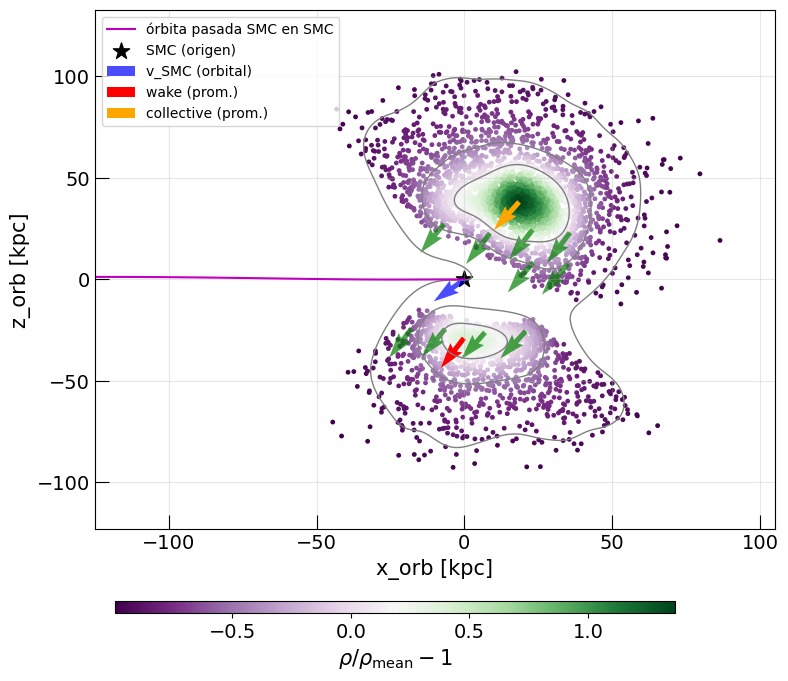

In [18]:
%matplotlib inline
fig, axs = plt.subplots(figsize=(8, 6))

#  PARTICULAS cerca del plano orbital y ~0
mask_plane = np.abs(WAKE_COL['y_orb']) < 100  

x = np.ravel(WAKE_COL[mask_plane]['x_orb'])
z = np.ravel(WAKE_COL[mask_plane]['z_orb'])

# kde de densidad en el plano x-z
density = gaussian_kde(np.vstack([x, z]))
density_values = density(np.vstack([x, z]))
mean_densidad_tot = density_values.mean()
maximo_densidad_tot = density_values.max()
print("densidad media, max =", mean_densidad_tot, maximo_densidad_tot)

# df reducido con sobredensidad normalizada
reducido = WAKE_COL[mask_plane][['x_orb', 'y_orb', 'z_orb']].copy()
reducido['densidad_norm'] = density_values / mean_densidad_tot - 1

# escater color por sobredensidad 
sc = axs.scatter(
    reducido['x_orb'],
    reducido['z_orb'],
    c=reducido['densidad_norm'],
    cmap='PRGn',
    s=6
)


cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.02])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label(label=r'$\rho/\rho_{\rm mean}-1$', size=15)
cb.ax.tick_params(labelsize=14)

# para los contornos de densidad
sns.kdeplot(
    x=reducido['x_orb'],
    y=reducido['z_orb'],
    levels=4,
    color="gray",
    linewidths=1,
    ax=axs
)

# aqui hago ña orbtia pasada de la SMC en el frame de la SMC MISMO plano orbital 
#  orbita a x_orb, z_orb ya rotadas con R2
axs.plot(
    pas_SMC_en_SMC['x_orb'],
    pas_SMC_en_SMC['z_orb'],
    c='m',
    label='órbita pasada SMC en SMC'
)


# origen de la SMC
# SMC en el origen y velocidad relativa SMC-LMC 
axs.scatter(0, 0, marker='*', s=150, c='k', label='SMC (origen)')
axs.quiver(
    0, 0,vsh_x,vsh_z,   
    color='blue',
    alpha=0.7,
    label='v_SMC (orbital)'
)

# velocidades promedios (binned) del halo 
mask_x = campoxz['cant'] > 25  # solo bins con suficiente número de partículas
axs.quiver(
    campoxz[mask_x]['x_orb'],
    campoxz[mask_x]['z_orb'],
    campoxz[mask_x]['vx_orb'],   # ya fueron restadas cuando hice campoxz
    campoxz[mask_x]['vz_orb'],
    color='g',
    alpha=0.7
)

# para el wake y la collective 
ppw = reducido[reducido['x_orb'] < 0]  # wake: lado izquierdo
mwake = ppw['densidad_norm']
ppc = reducido[reducido['x_orb'] > 0]  # collective: lado derecho
mcol = ppc['densidad_norm']

xp_w = ppw.iloc[np.argmax(mwake)]['x_orb']
zp_w = ppw.iloc[np.argmax(mwake)]['z_orb']
xp_c = ppc.iloc[np.argmax(mcol)]['x_orb']
zp_c = ppc.iloc[np.argmax(mcol)]['z_orb']

# mask cerca del plano para cada df
mask_w = np.abs(Wake_sur_SMC['y_orb']) < 100
mask_c = np.abs(Collective_SMC['y_orb']) < 100

# wake: marco comovil con la SMC (restadas vsh_x, vsh_z), me estoy moviendo con la SMC
axs.quiver(
    xp_w, zp_w,
    Wake_sur_SMC[mask_w]['vx_orb'].mean(), 
    Wake_sur_SMC[mask_w]['vz_orb'].mean(),
    color='r',
    label='wake (prom.)'
)

# collective igual que para el wake
axs.quiver(
    xp_c, zp_c,
    Collective_SMC[mask_c]['vx_orb'].mean() ,
    Collective_SMC[mask_c]['vz_orb'].mean() ,
    color='orange',
    label='collective (prom.)'
)


axs.grid(alpha=0.3)
axs.set_xlim(-125, 105)
axs.set_xlabel('x_orb [kpc]', fontsize=15)
axs.set_ylabel('z_orb [kpc]', fontsize=15)
axs.tick_params(axis='both', labelsize=14, direction='in', which='both', length=10)

axs.legend()

plt.tight_layout()
#plt.savefig('wake_collective_overdensity_orbital_frame_xz.pdf', bbox_inches='tight')
plt.show()


In [19]:
Wake_sur_LMC.columns

Index(['source_id', 'ra', 'dec', 'l', 'b', 'R_sol_kpc', 'pmra*', 'pmdec*',
       'rad_vel*', 'x_icrs_kpc', 'y_icrs_kpc', 'z_icrs_kpc', 'x_LMC_new',
       'y_LMC_new', 'z_LMC_new', 'd_LMC_new', 'lat_LMC_new', 'long_LMC_new',
       'vx_icrs', 'vy_icrs', 'vz_icrs', 'vx_LMC_new', 'vy_LMC_new',
       'vz_LMC_new', 'x_icrs_kpc_LMC', 'y_icrs_kpc_LMC', 'z_icrs_kpc_LMC',
       'vx_icrs_LMC', 'vy_icrs_LMC', 'vz_icrs_LMC'],
      dtype='object')

In [20]:
Wake_sur_SMC

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new,x_orb,y_orb,z_orb,vx_orb,vy_orb,vz_orb
0,5.912435e+18,262.780185,-60.279634,331.631105,-14.153433,45.866011,-0.125037,-0.503515,-68.222398,-2.857738,...,4.972718,-552.035088,-477.339910,-439.607316,28.951480,-26.633516,-3.892086,-552.035088,258.191468,-595.352961
1,5.912986e+18,263.115537,-59.095439,332.771305,-13.699324,72.886715,-0.132944,-0.437714,-98.319855,-4.487282,...,6.683565,-599.088929,-505.179603,-443.663586,46.076894,-6.159633,-8.264257,-599.088929,252.867396,-622.978241
2,4.194259e+18,293.203301,-10.154031,28.426114,-13.750024,40.142193,-0.042937,-0.135762,-50.212169,15.568100,...,-16.577782,-463.544613,-470.387897,-450.449849,32.831576,-51.152427,27.500891,-463.544613,270.717095,-592.353015
3,4.194775e+18,295.495165,-8.375545,31.095452,-15.012418,38.452541,0.003649,-0.183205,-50.641784,16.374791,...,-25.662552,-467.390219,-465.906126,-460.075287,30.540253,-52.222226,28.094413,-467.390219,281.281004,-591.285706
4,4.194619e+18,294.905959,-9.048722,30.205638,-14.782356,51.972131,-0.082394,-0.165903,-58.769770,21.614646,...,-31.122205,-460.377269,-487.479953,-464.714524,40.990483,-48.189577,35.696525,-460.377269,278.567935,-613.185289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3024,2.843659e+18,346.685399,25.927044,95.280377,-31.263061,39.851675,-0.020392,-0.269921,-38.222471,34.877275,...,-62.571944,-417.447774,-441.416726,-491.127296,-2.318322,-66.932931,44.118826,-417.447774,318.659146,-578.369342
3025,2.713602e+18,347.009403,8.268835,83.997455,-46.637907,35.000000,0.361360,0.082439,64.438370,33.749702,...,22.803167,-495.575723,-371.636072,-414.707522,-0.933836,-55.703392,38.922911,-495.575723,269.435913,-487.339704
3026,2.870105e+18,351.413889,29.961200,101.625412,-29.336984,32.939256,0.200289,-0.105293,39.722731,28.217549,...,5.593924,-466.872913,-391.705840,-428.520334,-4.113720,-68.271539,36.619941,-466.872913,275.880834,-510.835499
3027,2.437206e+18,353.846802,-9.664083,73.565274,-64.963974,43.944963,-0.254915,0.248706,70.797818,43.071755,...,39.190301,-396.598381,-342.776706,-386.039091,-5.048715,-40.773943,42.236668,-396.598381,251.851906,-450.658038


In [21]:
# columna con el identificador de las estrellas
col_id = 'source_id'   

ids_wake_LMC = Wake_sur_LMC[col_id].values
ids_wake_SMC = Wake_sur_SMC[col_id].values

# son el mismo counto de estrellas?
mismas_wake = (
    len(ids_wake_LMC) == len(ids_wake_SMC)
    and set(ids_wake_LMC) == set(ids_wake_SMC)
)

print("¿Wake_LMC y Wake_SMC tienen las MISMAS estrellas?", mismas_wake)
print("N_wake_LMC =", len(ids_wake_LMC), "  N_wake_SMC =", len(ids_wake_SMC))


¿Wake_LMC y Wake_SMC tienen las MISMAS estrellas? True
N_wake_LMC = 3029   N_wake_SMC = 3029


In [22]:
ids_coll_LMC = Collective_LMC[col_id].values
ids_coll_SMC = Collective_SMC[col_id].values

mismas_coll = (
    len(ids_coll_LMC) == len(ids_coll_SMC)
    and set(ids_coll_LMC) == set(ids_coll_SMC)
)

print("¿Collective_LMC y Collective_SMC tienen las MISMAS estrellas?", mismas_coll)
print("N_coll_LMC =", len(ids_coll_LMC), "  N_coll_SMC =", len(ids_coll_SMC))


¿Collective_LMC y Collective_SMC tienen las MISMAS estrellas? True
N_coll_LMC = 1554   N_coll_SMC = 1554


In [23]:
# Esto debería ser False (frames diferentes)
np.allclose(Wake_sur_LMC['x_LMC_new'], Wake_sur_SMC['x_SMC_new'])
# Esto también debería ser False (diferente origen / ejes)
np.allclose(Wake_sur_LMC['x_LMC_new'], Wake_sur_SMC['x_SMC_new'])


False

### **quiver 2d para estrellas en una banda de 25-35 kpc para el Wake y la Colelctive** 




In [24]:
# condicion para una banda en la LMC 

Wake_2535 = Wake_sur_LMC[(Wake_sur_LMC['d_LMC_new'] >= 25) & (Wake_sur_LMC['d_LMC_new'] <= 40)]


Coll_2535 = Collective_LMC[(Collective_LMC['d_LMC_new'] >= 25) & (Collective_LMC['d_LMC_new'] <= 40)]

In [25]:
Wake_2535
Coll_2535

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs,vx_LMC_new,vy_LMC_new,vz_LMC_new,x_icrs_kpc_LMC,y_icrs_kpc_LMC,z_icrs_kpc_LMC,vx_icrs_LMC,vy_icrs_LMC,vz_icrs_LMC
0,6.070120e+18,201.667777,-51.024946,308.571759,11.460572,39.318323,-0.123465,-0.187858,-70.228196,-22.983067,...,32.573346,-368.248479,-391.607294,-298.559108,-22.983067,-9.131104,-30.566846,57.851879,47.746344,32.573346
35,5.442535e+18,157.111585,-36.589947,273.388838,17.948030,30.845012,-0.029665,-0.468084,-204.949751,-22.816156,...,67.212744,-538.184418,-320.824716,-281.566619,-22.816156,9.632486,-18.386218,190.874677,-75.874805,67.212744
36,5.442551e+18,157.052399,-36.395181,273.234897,18.085022,30.223381,-0.296190,0.085328,27.306111,-22.402837,...,-6.361529,-299.479829,-370.881071,-330.489626,-22.402837,9.485270,-17.933079,-10.374861,50.475619,-6.361529
100,6.068526e+18,200.786208,-51.845211,307.906310,10.720033,40.700715,-0.366364,-0.006732,-60.302717,-23.507796,...,46.616303,-314.798137,-405.514800,-278.828626,-23.507796,-8.923299,-32.004789,10.698979,79.668892,46.616303
152,5.415940e+18,154.415253,-43.517598,275.585254,11.040065,43.412133,-0.089116,0.005932,-68.507529,-28.394092,...,48.057916,-382.121747,-340.445194,-284.445669,-28.394092,13.594876,-29.892610,51.969712,-4.549405,48.057916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,5.375346e+18,171.751933,-47.096812,288.337017,13.368270,36.966953,0.117408,-0.240533,-125.934496,-24.905375,...,63.552712,-451.323376,-330.506125,-276.129450,-24.905375,3.610250,-27.078479,112.449570,-37.090275,63.552712
1541,5.630355e+18,141.522326,-33.204658,260.937151,12.445563,29.415551,-0.193374,-0.025334,-29.423577,-19.267970,...,13.157448,-361.911412,-344.115563,-317.416504,-19.267970,15.314180,-16.108875,37.565410,4.587262,13.157448
1542,5.631120e+18,138.843271,-32.316503,258.690624,11.429104,28.871842,-0.313699,-0.114716,-20.301014,-18.370922,...,-2.416024,-365.857319,-357.772330,-333.489712,-18.370922,16.058035,-15.434765,47.493298,15.511065,-2.416024
1543,5.631238e+18,141.057733,-32.061953,259.819445,12.965195,33.115545,-0.044444,0.076676,-27.824299,-21.828063,...,24.971001,-348.010554,-327.985792,-304.078959,-21.828063,17.639629,-17.578921,17.755928,-5.378573,24.971001


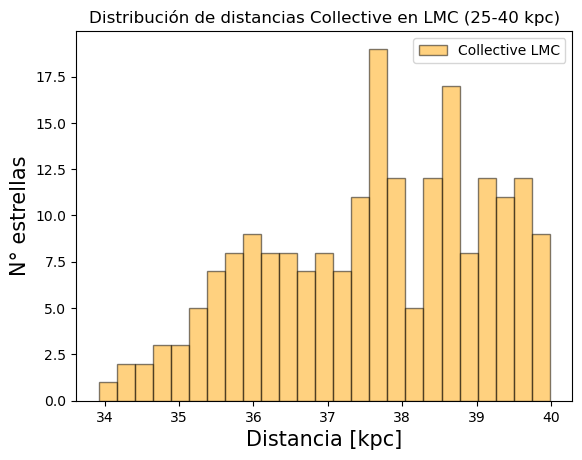

In [26]:
#plt.hist(Wake_2535['d_LMC_new'], bins=20, alpha=0.5, label='Wake LMC', color='blue')
plt.hist(Coll_2535['d_LMC_new'], bins=25, alpha=0.5, label='Collective LMC', color='orange', edgecolor='black')
plt.xlabel('Distancia [kpc]', fontsize=15)
plt.ylabel('N° estrellas', fontsize=15)
plt.legend()
plt.title('Distribución de distancias Collective en LMC (25-40 kpc)', fontsize=12)
plt.show()

In [27]:
Coll_2535['d_LMC_new'].min(), Coll_2535['d_LMC_new'].max()

(33.92212423624986, 39.98228584832932)

#### **Para el quiver, en el frame de la SMC, aplicamos la segunda rotación R2**


#### **Misma condicion para 25-35 kpc**

In [28]:
# condicion para una banda en la SMC

Wake_2535_SMC = Wake_sur_SMC[(Wake_sur_SMC['d_SMC_new'] >= 25) & (Wake_sur_SMC['d_SMC_new'] <= 40)]


Coll_2535_SMC = Collective_SMC[(Collective_SMC['d_SMC_new'] >= 25) & (Collective_SMC['d_SMC_new'] <= 40)]

In [29]:
Wake_2535_SMC


,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new,x_orb,y_orb,z_orb,vx_orb,vy_orb,vz_orb
0,5.912435e+18,262.780185,-60.279634,331.631105,-14.153433,45.866011,-0.125037,-0.503515,-68.222398,-2.857738,...,4.972718,-552.035088,-477.339910,-439.607316,28.951480,-26.633516,-3.892086,-552.035088,258.191468,-595.352961
81,2.308740e+18,4.164346,-36.428485,339.192960,-78.132258,42.687186,0.111442,-0.106690,2.892858,34.255375,...,-19.088678,-444.493793,-447.371378,-450.639463,-7.152401,-26.878549,26.295013,-444.493793,278.464876,-570.678884
130,6.572308e+18,327.609988,-41.527429,359.596314,-50.478163,49.003909,0.433810,-0.199900,13.539748,30.978617,...,-43.741101,-526.063566,-421.968508,-485.497005,15.713829,-21.693506,27.851303,-526.063566,319.737296,-558.151257
134,6.566715e+18,333.923192,-45.879043,351.074455,-54.025777,34.369380,0.353610,-0.112772,-13.585894,21.491470,...,-3.038286,-489.314696,-442.395161,-439.974118,8.756539,-32.169734,19.112228,-489.314696,270.029041,-562.472240
136,6.566977e+18,335.165936,-45.333531,351.503521,-55.021473,48.750116,0.294019,-0.103458,12.208429,31.101244,...,-25.490285,-494.408527,-428.141834,-463.220586,10.942435,-19.517327,25.630025,-494.408527,296.669726,-556.655922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,6.539162e+18,353.892119,-36.579054,357.737803,-71.373714,43.325406,0.092245,0.234159,-112.388744,34.594332,...,105.595789,-449.840816,-493.583292,-325.674648,-1.296555,-26.422315,28.351146,-449.840816,145.253576,-573.227565
2924,6.541344e+18,343.771328,-43.178676,351.002045,-61.541462,35.655564,0.404381,0.024609,-10.250472,24.964838,...,10.047401,-498.611351,-434.609349,-427.932053,4.646926,-31.164382,21.305578,-498.611351,261.216954,-551.159534
2925,6.542509e+18,347.837205,-41.142418,352.189261,-65.139012,49.837929,0.039447,0.265891,-221.710221,36.689295,...,193.177306,-452.769382,-555.554011,-237.794582,2.961378,-19.228727,29.242509,-452.769382,41.882506,-602.853530
2964,6.500665e+18,347.080916,-53.487562,331.715749,-57.493263,36.681083,0.353944,-0.224862,-11.186317,21.272680,...,-14.273828,-486.390864,-471.497423,-450.934954,4.040970,-27.644890,15.612058,-486.390864,270.810366,-593.560357


In [30]:
print(len(Wake_2535_SMC.columns), "columnas")
print(Wake_2535_SMC.columns.tolist())        # lista completa
for i, c in enumerate(Wake_2535_SMC.columns):
    print(i, repr(c))                   # con índice y mostrando espacios ocultos

51 columnas
['source_id', 'ra', 'dec', 'l', 'b', 'R_sol_kpc', 'pmra*', 'pmdec*', 'rad_vel*', 'x_icrs_kpc', 'y_icrs_kpc', 'z_icrs_kpc', 'x_LMC_new', 'y_LMC_new', 'z_LMC_new', 'd_LMC_new', 'lat_LMC_new', 'long_LMC_new', 'vx_icrs', 'vy_icrs', 'vz_icrs', 'vx_LMC_new', 'vy_LMC_new', 'vz_LMC_new', 'x_icrs_kpc_LMC', 'y_icrs_kpc_LMC', 'z_icrs_kpc_LMC', 'vx_icrs_LMC', 'vy_icrs_LMC', 'vz_icrs_LMC', 'x_icrs_kpc_SMC', 'y_icrs_kpc_SMC', 'z_icrs_kpc_SMC', 'x_SMC_new', 'y_SMC_new', 'z_SMC_new', 'd_SMC_new', 'lat_SMC_new', 'long_SMC_new', 'vx_icrs_SMC', 'vy_icrs_SMC', 'vz_icrs_SMC', 'vx_SMC_new', 'vy_SMC_new', 'vz_SMC_new', 'x_orb', 'y_orb', 'z_orb', 'vx_orb', 'vy_orb', 'vz_orb']
0 'source_id'
1 'ra'
2 'dec'
3 'l'
4 'b'
5 'R_sol_kpc'
6 'pmra*'
7 'pmdec*'
8 'rad_vel*'
9 'x_icrs_kpc'
10 'y_icrs_kpc'
11 'z_icrs_kpc'
12 'x_LMC_new'
13 'y_LMC_new'
14 'z_LMC_new'
15 'd_LMC_new'
16 'lat_LMC_new'
17 'long_LMC_new'
18 'vx_icrs'
19 'vy_icrs'
20 'vz_icrs'
21 'vx_LMC_new'
22 'vy_LMC_new'
23 'vz_LMC_new'
24 'x_icr

In [31]:
Coll_2535_SMC

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new,x_orb,y_orb,z_orb,vx_orb,vy_orb,vz_orb


In [32]:
print("N collective total:", len(Coll_2535_SMC))
print(Collective_SMC['d_SMC_new'].describe())


N collective total: 0
count    1554.000000
mean       72.670418
std        13.862935
min        51.086858
25%        62.361483
50%        70.168426
75%        79.634442
max       127.880570
Name: d_SMC_new, dtype: float64


In [33]:
print("N collective total:", len(Collective_SMC))
print("N collective con 25 <= d_LMC_new <= 35:",
      np.sum((Collective_SMC['d_LMC_new'] >= 25) &
             (Collective_SMC['d_LMC_new'] <= 35)))
print("N collective con 25 <= d_LMC_new <= 40:",
      np.sum((Collective_SMC['d_LMC_new'] >= 25) &
             (Collective_SMC['d_LMC_new'] <= 40)))


N collective total: 1554
N collective con 25 <= d_LMC_new <= 35: 10
N collective con 25 <= d_LMC_new <= 40: 206


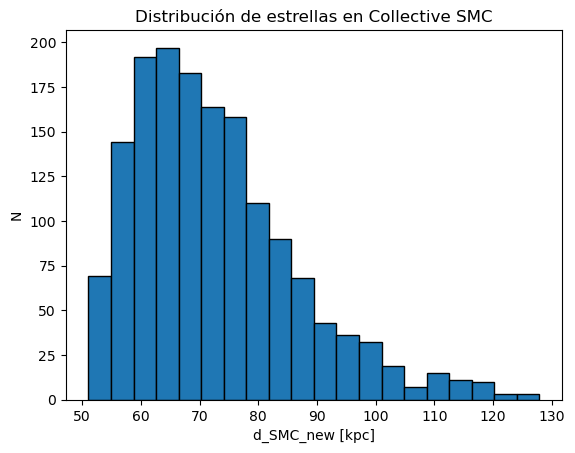

In [34]:
# rango fuera para la banda 25-35 kpc en la collective SMC
plt.hist(Collective_SMC['d_SMC_new'], bins=20, edgecolor='black')
plt.xlabel('d_SMC_new [kpc]')
plt.ylabel('N')
plt.title('Distribución de estrellas en Collective SMC')
plt.show()


In [35]:
ct, st = np.cos(theta), np.sin(theta) 

###################################### Wake 25–35 kpc en frame orbital 


x_w = Wake_2535_SMC['x_SMC_new'].values
y_w = Wake_2535_SMC['y_SMC_new'].values
z_w = Wake_2535_SMC['z_SMC_new'].values

Wake_2535_SMC['x_orb'] = x_w
Wake_2535_SMC['y_orb'] = ct*y_w + st*z_w
Wake_2535_SMC['z_orb'] = -st*y_w + ct*z_w

vx_w = Wake_2535_SMC['vx_SMC_new'].values
vy_w = Wake_2535_SMC['vy_SMC_new'].values
vz_w = Wake_2535_SMC['vz_SMC_new'].values

Wake_2535_SMC['vx_orb'] = vx_w
Wake_2535_SMC['vy_orb'] = ct*vy_w + st*vz_w
Wake_2535_SMC['vz_orb'] = -st*vy_w + ct*vz_w


#####################################3 Collective 25–35 kpc en frame orbital


x_c = Coll_2535_SMC['x_SMC_new'].values
y_c = Coll_2535_SMC['y_SMC_new'].values
z_c = Coll_2535_SMC['z_SMC_new'].values

Coll_2535_SMC['x_orb'] = x_c
Coll_2535_SMC['y_orb'] = ct*y_c + st*z_c
Coll_2535_SMC['z_orb'] = -st*y_c + ct*z_c

vx_c = Coll_2535_SMC['vx_SMC_new'].values
vy_c = Coll_2535_SMC['vy_SMC_new'].values
vz_c = Coll_2535_SMC['vz_SMC_new'].values

Coll_2535_SMC['vx_orb'] = vx_c
Coll_2535_SMC['vy_orb'] = ct*vy_c + st*vz_c
Coll_2535_SMC['vz_orb'] = -st*vy_c + ct*vz_c


/tmp/ipykernel_11824/1660694447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Wake_2535_SMC['x_orb'] = x_w

/tmp/ipykernel_11824/1660694447.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Wake_2535_SMC['y_orb'] = ct*y_w + st*z_w

/tmp/ipykernel_11824/1660694447.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [36]:
Coll_2535_SMC
Wake_2535_SMC

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new,x_orb,y_orb,z_orb,vx_orb,vy_orb,vz_orb
0,5.912435e+18,262.780185,-60.279634,331.631105,-14.153433,45.866011,-0.125037,-0.503515,-68.222398,-2.857738,...,4.972718,-552.035088,-477.339910,-439.607316,28.951480,-26.633516,-3.892086,-552.035088,258.191468,-595.352961
81,2.308740e+18,4.164346,-36.428485,339.192960,-78.132258,42.687186,0.111442,-0.106690,2.892858,34.255375,...,-19.088678,-444.493793,-447.371378,-450.639463,-7.152401,-26.878549,26.295013,-444.493793,278.464876,-570.678884
130,6.572308e+18,327.609988,-41.527429,359.596314,-50.478163,49.003909,0.433810,-0.199900,13.539748,30.978617,...,-43.741101,-526.063566,-421.968508,-485.497005,15.713829,-21.693506,27.851303,-526.063566,319.737296,-558.151257
134,6.566715e+18,333.923192,-45.879043,351.074455,-54.025777,34.369380,0.353610,-0.112772,-13.585894,21.491470,...,-3.038286,-489.314696,-442.395161,-439.974118,8.756539,-32.169734,19.112228,-489.314696,270.029041,-562.472240
136,6.566977e+18,335.165936,-45.333531,351.503521,-55.021473,48.750116,0.294019,-0.103458,12.208429,31.101244,...,-25.490285,-494.408527,-428.141834,-463.220586,10.942435,-19.517327,25.630025,-494.408527,296.669726,-556.655922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,6.539162e+18,353.892119,-36.579054,357.737803,-71.373714,43.325406,0.092245,0.234159,-112.388744,34.594332,...,105.595789,-449.840816,-493.583292,-325.674648,-1.296555,-26.422315,28.351146,-449.840816,145.253576,-573.227565
2924,6.541344e+18,343.771328,-43.178676,351.002045,-61.541462,35.655564,0.404381,0.024609,-10.250472,24.964838,...,10.047401,-498.611351,-434.609349,-427.932053,4.646926,-31.164382,21.305578,-498.611351,261.216954,-551.159534
2925,6.542509e+18,347.837205,-41.142418,352.189261,-65.139012,49.837929,0.039447,0.265891,-221.710221,36.689295,...,193.177306,-452.769382,-555.554011,-237.794582,2.961378,-19.228727,29.242509,-452.769382,41.882506,-602.853530
2964,6.500665e+18,347.080916,-53.487562,331.715749,-57.493263,36.681083,0.353944,-0.224862,-11.186317,21.272680,...,-14.273828,-486.390864,-471.497423,-450.934954,4.040970,-27.644890,15.612058,-486.390864,270.810366,-593.560357


In [37]:
# Ne nuevo concatenación de wake y collective 25-35 kpc SMC en frame orbital

WAKE_COL_2535_SMC = pd.concat([Wake_2535_SMC, Coll_2535_SMC], ignore_index=True)

In [38]:

stepx = 15
stepz = 15

x_mean, z_mean = [], []
vx_mean, vz_mean = [], []
cant = []

for ix in np.arange(-75, 50, stepx):
    for iz in np.arange(-30, 25, stepz):
        # aqui selecciono todas las entre del wake y collective que caen en ese rectamgulito del plano orbital
        maskx = (WAKE_COL_2535_SMC['x_orb'] > ix) & (WAKE_COL_2535_SMC['x_orb'] < ix + stepx)
        maskz = (WAKE_COL_2535_SMC['z_orb'] > iz) & (WAKE_COL_2535_SMC['z_orb'] < iz + stepz)

        bin_df = WAKE_COL_2535_SMC[maskx & maskz]
        if len(bin_df) == 0:
            continue

        #si hay estrellas en ese bin, calculo los promedios de posiciones y velocidades
        x_mean.append(bin_df['x_orb'].mean())
        z_mean.append(bin_df['z_orb'].mean())

        
        vx_mean.append(bin_df['vx_orb'].mean() )
        vz_mean.append(bin_df['vz_orb'].mean() )




        cant.append(len(bin_df))

#frame comovil con la SMC en el plano x–z
campoxz_2535_SMC = pd.DataFrame({
    'x_orb':  x_mean,           # posicones del centro del bin... de ahi sale la flecha verde
    'z_orb':  z_mean,           # igual 
    'vx_orb': vx_mean,          # flujo medio del halo en ese bin
    'vz_orb': vz_mean,
    'cant':   cant
}).reset_index(drop=True)


### **quiver 2d**

##### **... muestra cómo se mueve el wake y colelctive en el frame orbital cntrado en la SMC**

densidad media, max = 0.0010633964909782783 0.0020741385372462545
/tmp/ipykernel_11824/1716755416.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()

/home/marz/anaconda3/envs/NaMaster/lib/python3.12/site-packages/matplotlib/quiver.py:630: RuntimeWarning: Mean of empty slice.
  amean = a[~self.Umask].mean()

/home/marz/anaconda3/envs/NaMaster/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



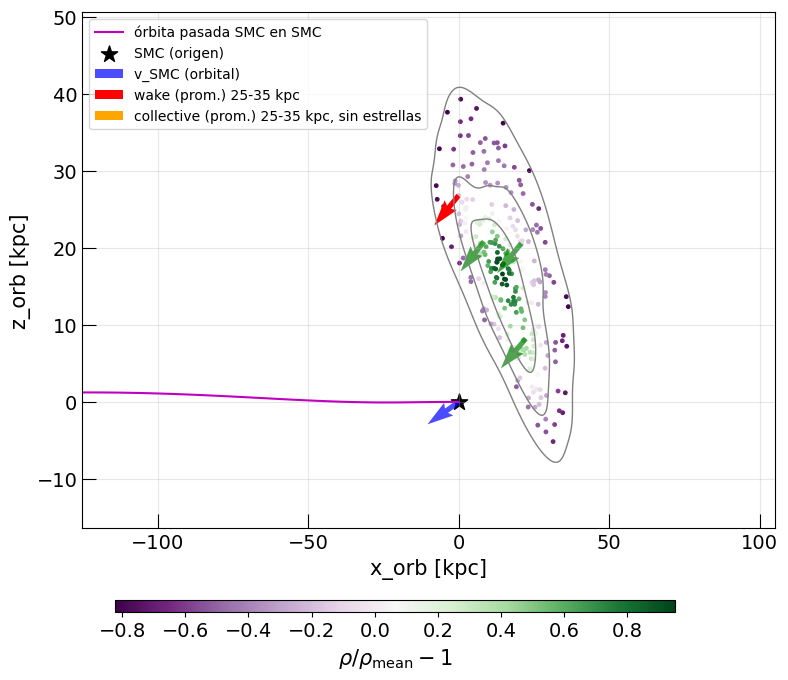

In [43]:
%matplotlib inline
fig, axs = plt.subplots(figsize=(8, 6))

#  PARTICULAS cerca del plano orbital y ~0
mask_plane = np.abs(WAKE_COL_2535_SMC['y_orb']) < 100  

x = np.ravel(WAKE_COL_2535_SMC[mask_plane]['x_orb'])
z = np.ravel(WAKE_COL_2535_SMC[mask_plane]['z_orb'])

# kde de densidad en el plano x-z
density = gaussian_kde(np.vstack([x, z]))
density_values = density(np.vstack([x, z]))
mean_densidad_tot = density_values.mean()
maximo_densidad_tot = density_values.max()
print("densidad media, max =", mean_densidad_tot, maximo_densidad_tot)

# df reducido con sobredensidad normalizada
reducido = WAKE_COL_2535_SMC[mask_plane][['x_orb', 'y_orb', 'z_orb']].copy()
reducido['densidad_norm'] = density_values / mean_densidad_tot - 1

# escater color por sobredensidad 
sc = axs.scatter(
    reducido['x_orb'],
    reducido['z_orb'],
    c=reducido['densidad_norm'],
    cmap='PRGn',
    s=6
)


cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.02])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label(label=r'$\rho/\rho_{\rm mean}-1$', size=15)
cb.ax.tick_params(labelsize=14)

# para los contornos de densidad
sns.kdeplot(
    x=reducido['x_orb'],
    y=reducido['z_orb'],
    levels=4,
    color="gray",
    linewidths=1,
    ax=axs
)

# aqui hago ña orbtia pasada de la SMC en el frame de la SMC MISMO plano orbital 
#  orbita a x_orb, z_orb ya rotadas con R2
axs.plot(
    pas_SMC_en_SMC['x_orb'],
    pas_SMC_en_SMC['z_orb'],
    c='m',
    label='órbita pasada SMC en SMC'
)


# origen de la SMC
# SMC en el origen y velocidad relativa SMC-LMC 
axs.scatter(0, 0, marker='*', s=150, c='k', label='SMC (origen)')
axs.quiver(
    0, 0,vsh_x,vsh_z,   
    color='blue',
    alpha=0.7,
    label='v_SMC (orbital)'
)

# velocidades promedios (binned) del halo en el plano orbital (no comovil)
mask_x = campoxz_2535_SMC['cant'] > 25  # solo bins con suficiente número de partículas
axs.quiver(
    campoxz_2535_SMC[mask_x]['x_orb'],
    campoxz_2535_SMC[mask_x]['z_orb'],
    campoxz_2535_SMC[mask_x]['vx_orb'],   
    campoxz_2535_SMC[mask_x]['vz_orb'],
    color='g',
    alpha=0.7
)

# para el wake y la collective 
ppw = reducido[reducido['x_orb'] < 0]  # wake: lado izquierdo
mwake = ppw['densidad_norm']
ppc = reducido[reducido['x_orb'] > 0]  # collective: lado derecho
mcol = ppc['densidad_norm']

xp_w = ppw.iloc[np.argmax(mwake)]['x_orb']
zp_w = ppw.iloc[np.argmax(mwake)]['z_orb']
xp_c = ppc.iloc[np.argmax(mcol)]['x_orb']
zp_c = ppc.iloc[np.argmax(mcol)]['z_orb']

# mask cerca del plano para cada df
mask_w = np.abs(Wake_2535_SMC['y_orb']) < 100
mask_c = np.abs(Coll_2535_SMC['y_orb']) < 100

# wake: marco comovil con la SMC (restadas vsh_x, vsh_z), me estoy moviendo con la SMC
axs.quiver(
    xp_w, zp_w,
    Wake_2535_SMC[mask_w]['vx_orb'].mean(), 
    Wake_2535_SMC[mask_w]['vz_orb'].mean(),
    color='r',
    label='wake (prom.) 25-35 kpc'
)

# collective igual que para la collective
axs.quiver(
    xp_c, zp_c,
    Coll_2535_SMC[mask_c]['vx_orb'].mean() ,
    Coll_2535_SMC[mask_c]['vz_orb'].mean() ,
    color='orange',
    label='collective (prom.) 25-35 kpc, sin estrellas'
)


axs.grid(alpha=0.3)
axs.set_xlim(-125, 105)
axs.set_xlabel('x_orb [kpc]', fontsize=15)
axs.set_ylabel('z_orb [kpc]', fontsize=15)
axs.tick_params(axis='both', labelsize=14, direction='in', which='both', length=10)

axs.legend()

plt.tight_layout()
#plt.savefig('wake_collective_overdensity_orbital_frame_xz.pdf', bbox_inches='tight')
plt.show()


In [40]:
print("Wake_2535_SMC:", len(Wake_2535_SMC))
print("Coll_2535_SMC:", len(Coll_2535_SMC))


Wake_2535_SMC: 258
Coll_2535_SMC: 0


In [41]:
mask_w = np.abs(Wake_2535_SMC['y_orb']) < 100
mask_c = np.abs(Coll_2535_SMC['y_orb']) < 100

print("Wake 25–35 & |y_orb|<100:", mask_w.sum())
print("Coll 25–35 & |y_orb|<100:", mask_c.sum())


Wake 25–35 & |y_orb|<100: 258
Coll 25–35 & |y_orb|<100: 0
